In [105]:
import gymnasium as gym
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from collections import deque, namedtuple

In [106]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Semilla configurada:", SEED)

Semilla configurada: 42


In [107]:
env = gym.make("CartPole-v1")

state, info = env.reset(seed=42)

print("Estado inicial:", state)
print("Dimensión del estado:", env.observation_space.shape)
print("Número de acciones:", env.action_space.n)

Estado inicial: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Dimensión del estado: (4,)
Número de acciones: 2


In [108]:
env = gym.make("CartPole-v1")

state, info = env.reset(seed=SEED)

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("Número de entradas:", state_size)
print("Número de acciones:", action_size)

Número de entradas: 4
Número de acciones: 2


In [109]:
class DQN(nn.Module):

    def __init__(self, state_size, action_size):
        super().__init__()

        self.layer1 = nn.Linear(state_size, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, action_size)

    def forward(self, x):

        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))

        return self.layer3(x)

In [110]:
policy_net = DQN(state_size, action_size)

print(policy_net)

DQN(
  (layer1): Linear(in_features=4, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=2, bias=True)
)


In [111]:
state_tensor = torch.tensor(
    state,
    dtype=torch.float32
).unsqueeze(0)

with torch.no_grad():
    q_values = policy_net(state_tensor)

print("Estado:", state)
print("Q-values:", q_values)

Estado: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Q-values: tensor([[ 0.0207, -0.0128]])


In [112]:
target_net = DQN(state_size, action_size)

target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()

print("Target Network creada correctamente")

Target Network creada correctamente


In [113]:
Transition = namedtuple(
    "Transition",
    ("state", "action", "next_state", "reward", "done")
)


class ReplayMemory:

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(
            Transition(*args)
        )

    def sample(self, batch_size):
        return random.sample(
            self.memory,
            batch_size
        )

    def __len__(self):
        return len(self.memory)

In [114]:
memory = ReplayMemory(10000)

print("Capacidad del Replay Buffer: 10000")
print("Experiencias almacenadas:", len(memory))

Capacidad del Replay Buffer: 10000
Experiencias almacenadas: 0


In [115]:
BATCH_SIZE = 64

GAMMA = 0.99

LEARNING_RATE = 0.001

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 500

TARGET_UPDATE = 10

NUM_EPISODES = 300

In [116]:
print("Batch size:", BATCH_SIZE)
print("Gamma:", GAMMA)
print("Learning rate:", LEARNING_RATE)
print("Episodios:", NUM_EPISODES)

Batch size: 64
Gamma: 0.99
Learning rate: 0.001
Episodios: 300


In [117]:
criterion = nn.SmoothL1Loss()

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: SmoothL1Loss()
Optimizer: Adam


In [118]:
steps_done = 0


def select_action(state):

    global steps_done

    epsilon = (
        EPS_END
        + (EPS_START - EPS_END)
        * math.exp(
            -1.0 * steps_done / EPS_DECAY
        )
    )

    steps_done += 1

    if random.random() < epsilon:

        # Exploración
        action = env.action_space.sample()

    else:

        # Explotación
        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():

            q_values = policy_net(
                state_tensor
            )

            action = q_values.argmax(
                dim=1
            ).item()

    return action

In [119]:
state, info = env.reset(seed=42)

for i in range(10):

    action = select_action(state)

    print(
        f"Prueba {i + 1}: acción = {action}"
    )

Prueba 1: acción = 0
Prueba 2: acción = 1
Prueba 3: acción = 0
Prueba 4: acción = 0
Prueba 5: acción = 0
Prueba 6: acción = 0
Prueba 7: acción = 1
Prueba 8: acción = 0
Prueba 9: acción = 0
Prueba 10: acción = 1


In [120]:
state, info = env.reset(seed=42)

action = select_action(state)

next_state, reward, terminated, truncated, info = env.step(action)

done = terminated or truncated

memory.push(
    state,
    action,
    next_state,
    reward,
    done
)

print("Estado:", state)
print("Acción:", action)
print("Recompensa:", reward)
print("Nuevo estado:", next_state)
print("Terminado:", done)

print(
    "\nExperiencias almacenadas:",
    len(memory)
)

Estado: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Acción: 0
Recompensa: 1.0
Nuevo estado: [ 0.02727336 -0.20172954  0.03625453  0.32351476]
Terminado: False

Experiencias almacenadas: 1


In [121]:
# Reiniciar redes

policy_net = DQN(
    state_size,
    action_size
)

target_net = DQN(
    state_size,
    action_size
)

target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()


# Reiniciar optimizador

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)


# Reiniciar Replay Buffer

memory = ReplayMemory(10000)


# Reiniciar exploración

steps_done = 0


print("DQN reiniciado correctamente")

DQN reiniciado correctamente


In [122]:
def optimize_model():

    # No entrenamos hasta tener suficientes experiencias
    if len(memory) < BATCH_SIZE:
        return None

    # Tomamos una muestra aleatoria del Replay Buffer
    transitions = memory.sample(BATCH_SIZE)

    batch = Transition(*zip(*transitions))

    # Estados actuales
    states = torch.tensor(
        np.array(batch.state),
        dtype=torch.float32
    )

    # Acciones realizadas
    actions = torch.tensor(
        batch.action,
        dtype=torch.int64
    ).unsqueeze(1)

    # Recompensas obtenidas
    rewards = torch.tensor(
        batch.reward,
        dtype=torch.float32
    )

    # Siguientes estados
    next_states = torch.tensor(
        np.array(batch.next_state),
        dtype=torch.float32
    )

    # Indica si terminó el episodio
    dones = torch.tensor(
        batch.done,
        dtype=torch.bool
    )

    # Q(s,a) predicho por la Policy Network
    current_q_values = policy_net(states)

    current_q_values = current_q_values.gather(
        1,
        actions
    ).squeeze()

    # Calculamos el Q objetivo
    with torch.no_grad():

        next_q_values = target_net(
            next_states
        ).max(1)[0]

        # Si terminó el episodio, no hay recompensa futura
        next_q_values[dones] = 0.0

    # Ecuación de Bellman
    expected_q_values = (
        rewards
        + GAMMA * next_q_values
    )

    # Calculamos el error
    loss = criterion(
        current_q_values,
        expected_q_values
    )

    # Reiniciamos gradientes anteriores
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Actualizamos pesos con Adam
    optimizer.step()

    return loss.item()

In [123]:
episode_rewards = []
losses = []

for episode in range(NUM_EPISODES):

    state, info = env.reset()

    total_reward = 0

    for step in range(500):

        # 1. Elegir acción
        action = select_action(state)

        # 2. Ejecutar acción en CartPole
        next_state, reward, terminated, truncated, info = env.step(
            action
        )

        done = terminated or truncated

        # 3. Guardar experiencia
        memory.push(
            state,
            action,
            next_state,
            reward,
            done
        )

        # 4. Aprender
        loss = optimize_model()

        if loss is not None:
            losses.append(loss)

        # 5. Actualizar estado
        state = next_state

        total_reward += reward

        if done:
            break

    # Guardar recompensa del episodio
    episode_rewards.append(total_reward)

    # Actualizar Target Network
    if (episode + 1) % TARGET_UPDATE == 0:

        target_net.load_state_dict(
            policy_net.state_dict()
        )

    # Mostrar progreso
    if (episode + 1) % 25 == 0:

        average_reward = np.mean(
            episode_rewards[-25:]
        )

        print(
            f"Episodio {episode + 1}/{NUM_EPISODES} | "
            f"Reward promedio: {average_reward:.2f}"
        )

Episodio 25/300 | Reward promedio: 16.44
Episodio 50/300 | Reward promedio: 42.00
Episodio 75/300 | Reward promedio: 172.96
Episodio 100/300 | Reward promedio: 163.44
Episodio 125/300 | Reward promedio: 70.84
Episodio 150/300 | Reward promedio: 56.80
Episodio 175/300 | Reward promedio: 188.36
Episodio 200/300 | Reward promedio: 148.68
Episodio 225/300 | Reward promedio: 110.92
Episodio 250/300 | Reward promedio: 118.88
Episodio 275/300 | Reward promedio: 112.20
Episodio 300/300 | Reward promedio: 121.16


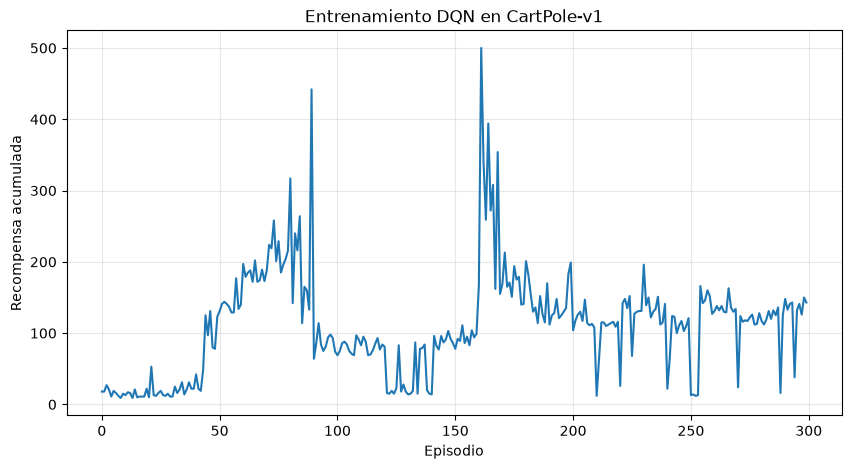

In [124]:
plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")

plt.title(
    "Entrenamiento DQN en CartPole-v1"
)

plt.grid(alpha=0.3)

plt.show()

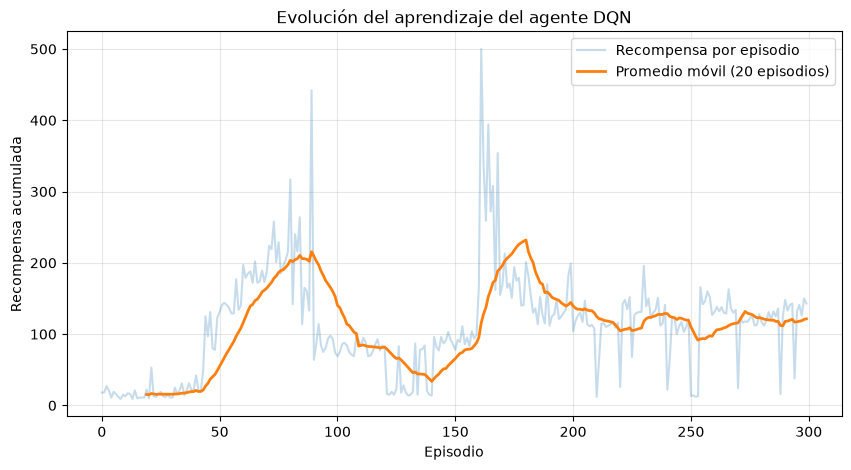

In [125]:
window = 20

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.25,
    label="Recompensa por episodio"
)

plt.plot(
    range(
        window - 1,
        len(episode_rewards)
    ),
    moving_average,
    linewidth=2,
    label="Promedio móvil (20 episodios)"
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")

plt.title(
    "Evolución del aprendizaje del agente DQN"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

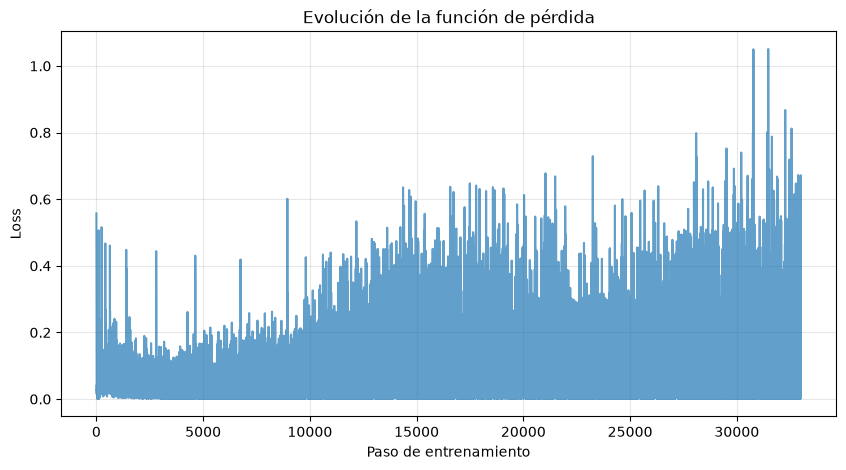

In [126]:
plt.figure(figsize=(10, 5))

plt.plot(
    losses,
    alpha=0.7
)

plt.xlabel("Paso de entrenamiento")
plt.ylabel("Loss")

plt.title(
    "Evolución de la función de pérdida"
)

plt.grid(alpha=0.3)

plt.show()

In [127]:
policy_net.eval()

test_rewards = []

NUM_TEST_EPISODES = 20

for episode in range(NUM_TEST_EPISODES):

    state, info = env.reset(seed=1000 + episode)
    total_reward = 0

    for step in range(500):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = policy_net(state_tensor)
            action = q_values.argmax(dim=1).item()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            break

    test_rewards.append(total_reward)

    print(
        f"Episodio {episode + 1}: "
        f"{total_reward:.0f}"
    )

print("\n-----------------------")
print("Reward promedio:", np.mean(test_rewards))
print("Mejor episodio:", np.max(test_rewards))
print("Peor episodio:", np.min(test_rewards))
print("Desviación estándar:", np.std(test_rewards))

Episodio 1: 126
Episodio 2: 128
Episodio 3: 125
Episodio 4: 126
Episodio 5: 132
Episodio 6: 126
Episodio 7: 127
Episodio 8: 125
Episodio 9: 127
Episodio 10: 132
Episodio 11: 121
Episodio 12: 129
Episodio 13: 126
Episodio 14: 125
Episodio 15: 120
Episodio 16: 126
Episodio 17: 127
Episodio 18: 116
Episodio 19: 120
Episodio 20: 126

-----------------------
Reward promedio: 125.5
Mejor episodio: 132.0
Peor episodio: 116.0
Desviación estándar: 3.7616485747608057


In [128]:
import os
import json

os.makedirs("results", exist_ok=True)

# Guardar modelo actual
torch.save(
    policy_net.state_dict(),
    "dqn_cartpole_baseline.pth"
)

# Guardar métricas de evaluación
evaluation_results = {
    "episodes": NUM_TEST_EPISODES,
    "average_reward": float(np.mean(test_rewards)),
    "best_reward": float(np.max(test_rewards)),
    "worst_reward": float(np.min(test_rewards)),
    "std_reward": float(np.std(test_rewards))
}

with open(
    "results/baseline_metrics.json",
    "w"
) as file:
    json.dump(
        evaluation_results,
        file,
        indent=4
    )

print("Modelo baseline guardado.")
print(evaluation_results)

Modelo baseline guardado.
{'episodes': 20, 'average_reward': 125.5, 'best_reward': 132.0, 'worst_reward': 116.0, 'std_reward': 3.7616485747608057}


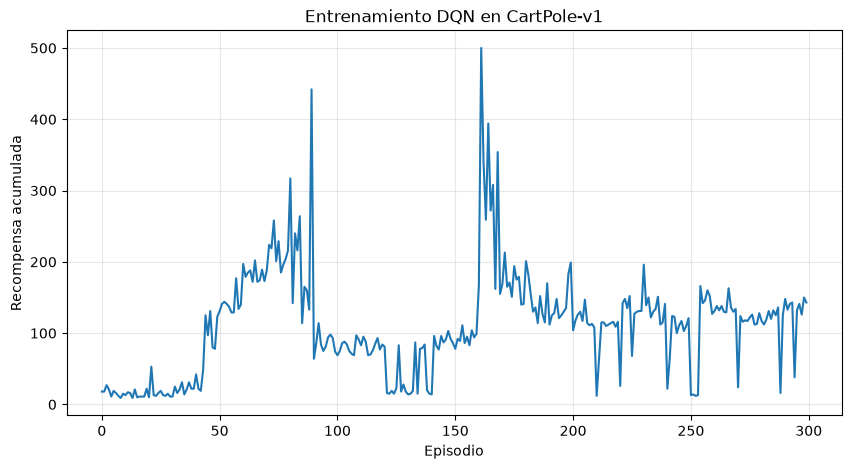

In [129]:
plt.figure(figsize=(10, 5))

plt.plot(episode_rewards)

plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.title("Entrenamiento DQN en CartPole-v1")
plt.grid(alpha=0.3)

plt.savefig(
    "results/reward_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

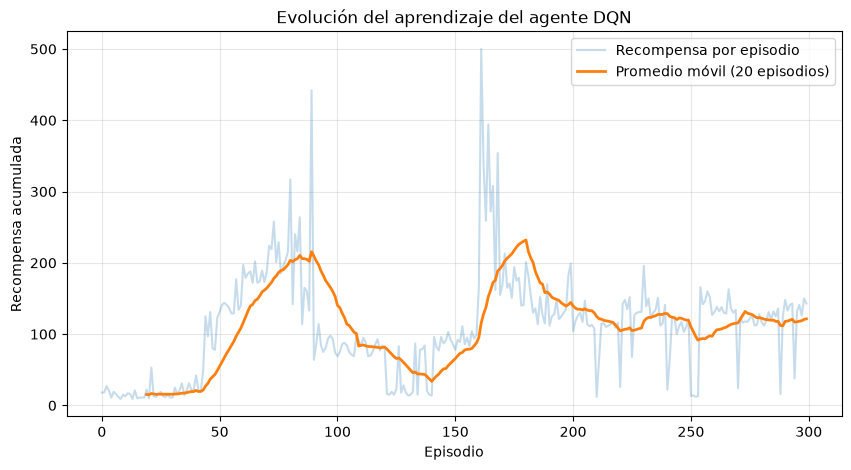

In [130]:
window = 20

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.25,
    label="Recompensa por episodio"
)

plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    linewidth=2,
    label="Promedio móvil (20 episodios)"
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.title("Evolución del aprendizaje del agente DQN")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "results/reward_moving_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

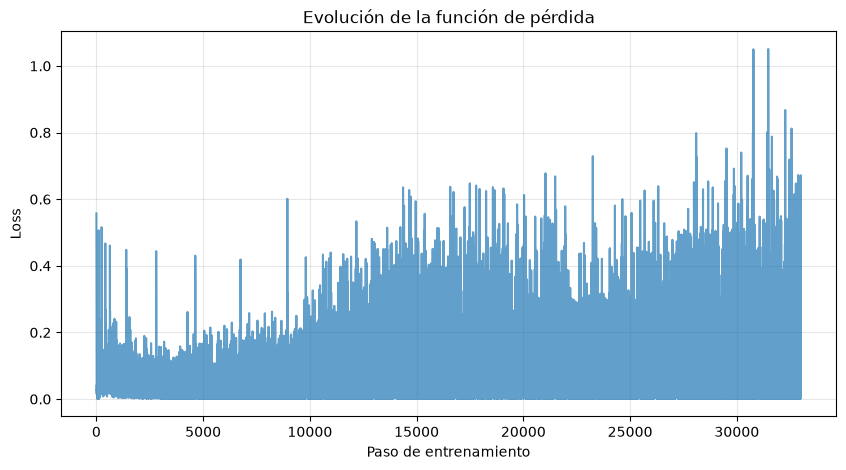

In [131]:
plt.figure(figsize=(10, 5))

plt.plot(losses, alpha=0.7)

plt.xlabel("Paso de entrenamiento")
plt.ylabel("Loss")
plt.title("Evolución de la función de pérdida")
plt.grid(alpha=0.3)

plt.savefig(
    "results/loss_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [132]:
import json

evaluation_results = {
    "test_episodes": NUM_TEST_EPISODES,
    "average_reward": float(np.mean(test_rewards)),
    "best_reward": float(np.max(test_rewards)),
    "worst_reward": float(np.min(test_rewards)),
    "standard_deviation": float(np.std(test_rewards))
}

with open(
    "results/evaluation_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        evaluation_results,
        file,
        indent=4,
        ensure_ascii=False
    )

print(evaluation_results)

{'test_episodes': 20, 'average_reward': 125.5, 'best_reward': 132.0, 'worst_reward': 116.0, 'standard_deviation': 3.7616485747608057}


In [133]:
import csv

with open(
    "results/test_rewards.csv",
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "episode",
        "reward"
    ])

    for i, reward in enumerate(
        test_rewards,
        start=1
    ):
        writer.writerow([
            i,
            reward
        ])

print("Resultados de prueba guardados")

Resultados de prueba guardados
